In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['GOOGLE_API_KEY']=os.getenv("GOOGLE_PAID_API_KEY")
os.getenv("GOOGLE_PAID_API_KEY")

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI

greet=ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7).invoke("hello")
greet

AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c9af8-1cbd-7aa3-befc-0d60ad0af2a9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 191, 'total_tokens': 193, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 182}})

In [34]:
greet.content

[{'type': 'text',
  'text': 'Hello! How can I help you today?',
  'extras': {'signature': 'EvIBCu8BAXLI2nwv4QPnvZN1mZeQlDlvV36jlrV9PWgYb4ViKwB9qIHeE5DBgU+ksxMuYjCNZIXOkV4p8YgwgGbS5CH0URupbIJSS9G1WkMMsWSIzsAD5RJXyxcmTVec6Nm6ip3A71J1oB4b9YwkGjZrG+ObgFob4UkPHJcHSro0sNMQ7ANBy8eEEtNIvv+y+TanfJB7CRgwOZsA5BSPOeaoZgMAChpoGAYLxOMaUL1qgCksvX04xn4dfJ+KF+EZOPioIkgUt/MRjiYPagLIk9OVRPMEoOjddlf2+E80/csTmCeJNJWqXh+oDF/qnRx29rSvEnw='}}]

In [3]:
from langchain_core.messages.content import create_text_block, create_image_block, ImageContentBlock
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from typing import Literal, List, cast
from pathlib import Path
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
load_dotenv()


import base64
def local_image_message_content(path:Path)->ImageContentBlock:
    return create_image_block(
        base64=base64.b64encode(path.read_bytes()).decode("utf-8"),
        mime_type=f"image/{path.suffix.lstrip('.')}"
    )

class AgentState(BaseModel):
    room_image_path: Path= Field(description="Path to the image of the room to be re innovated.")
    theme_samples: List[Path] = Field(
        description="List of paths to sample images representing the desired theme for the room."
    )
    reinnovation_description: str = Field(
        description="A detailed description of the desired re-innovation for the room."
    )

class Plans(BaseModel):
    steps: List[str] = Field(description="""
        List of step by step re innovation plans.
        Each step contains detailed description about what change to made, what to add, what to remove, what to change, where to apply, how to apply etc,
        with proper description of goal aesthetic, look, also position, color description etc,
        so that any editor specialist can read it and apply these changes on appropriate position, item on the actual room image precisely.
    """)


agent_state=AgentState(
    room_image_path=Path("samples/room.jpeg"),
    theme_samples=[
        Path("samples/gaming_theme.png")
    ],
    reinnovation_description="cozy beautiful gaming room"
)
# 1. Use 'model' instead of 'model_name'
llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.7, google_api_key=os.getenv("GOOGLE_API_KEY")).with_structured_output(Plans)

# 2. Wrap Content Blocks in a list [] for strict typing
messages = [
    SystemMessage(
        content="""
        You are an expert in room re innovation.
        You look into the room image provided provided, analyze its look, aesthetics, then you also look into the style inspiration images (if any), descriptions.
        Based on the desired look and aesthetic you make step by step plan of what changes to made.
        your step by step plan should not include modification of solid structures, 
        like for example: room size, window position, size, fixed light-fan-switch board positions, wiring, tiles etc.
        Your step by step re innovation plan should only contain modification, addition or removal of movable items. 
        some example are: portrait, table light, small table, bed, bedsheet, carpet, aquarium, twinkle lights etc etc.
        Give the output as json format.
        output example:
        ```
        { 
            steps: [
                "change the curtain to a beautiful red colored silky curtain with lily flower on it",
                "apply maroon plastic paint on the light pink wall on the left side",
            ]
        }
        ```
        """
    ),
    HumanMessage(
        content=[
            dict(
                create_text_block(text=f"""
                The following is the image of the room, on which you need to plan re innovation:
                """)
            ),
            dict(
                local_image_message_content(path=agent_state.room_image_path)
            ),
            dict(
                create_text_block(text=f"""
                    The following is the description about the re innovation I want:
                    ------------
                    {agent_state.reinnovation_description}
                    ------------

                    The following are some sample images of the theme I want:
                """)
            ),
            *[
                dict(
                    local_image_message_content(path=img_path)
                )
                for img_path in agent_state.theme_samples
            ]
        ]
    ),
]
# 3. .invoke() returns an AIMessage directly
response = cast(Plans,llm.invoke(messages))


In [4]:
response

Plans(steps=['Remove the child portrait, sticky notes, and the white lap desk from the bed area to clear the space for a new aesthetic.', 'Repaint the current dark pink and light pink walls to a uniform deep charcoal grey or matte black to create a dark, moody atmosphere that makes neon lights pop.', 'Replace the purple and white patterned curtains with heavy black blackout curtains to control lighting and match the gaming theme.', 'Remove the blue denim fabric from the top window opening and replace it with a black acoustic foam panel or a dark-tinted glass insert.', 'Change the bedsheet and pillowcases to a solid dark grey or black silk material to add a touch of luxury and maintain the dark color palette.', 'Install RGB LED strips along the entire perimeter where the walls meet the ceiling, programmed to show a blue and magenta gradient.', 'Apply black hexagonal acoustic foam panels in a geometric pattern on the wall behind the bed or where the gaming setup will be placed.', "Mount 

In [7]:
plans_listed=("\n-- ").join(response.steps)
print(plans_listed)

Remove the child portrait, sticky notes, and the white lap desk from the bed area to clear the space for a new aesthetic.
-- Repaint the current dark pink and light pink walls to a uniform deep charcoal grey or matte black to create a dark, moody atmosphere that makes neon lights pop.
-- Replace the purple and white patterned curtains with heavy black blackout curtains to control lighting and match the gaming theme.
-- Remove the blue denim fabric from the top window opening and replace it with a black acoustic foam panel or a dark-tinted glass insert.
-- Change the bedsheet and pillowcases to a solid dark grey or black silk material to add a touch of luxury and maintain the dark color palette.
-- Install RGB LED strips along the entire perimeter where the walls meet the ceiling, programmed to show a blue and magenta gradient.
-- Apply black hexagonal acoustic foam panels in a geometric pattern on the wall behind the bed or where the gaming setup will be placed.
-- Mount a large, neon-

In [8]:
message=[
    SystemMessage(
        content="""
            You are an image editor, expert in re innovating interior room design by following step by step editing plans given.
            you generate high fidality beautiful aesthetic room based on the image of the room, planning given to you.
            You only change the movable items in the scene. You do not add or modify extra item that is not present in the plan.
            You do not change rigit structure of the room and do not change the visual perspective of the given image.
        """
    ),
    HumanMessage(
        content=[
            dict(
                create_text_block(
                    text="The following is the image, on which you need to apply the style changes and do the re innovation on:"
                )
            ),
            dict(local_image_message_content(path=agent_state.room_image_path)),
            dict(
                create_text_block(
                    text=f"""
                    The following is the step by step plan of re innovation, apply these to the given image:
                    {plans_listed}
                    """
                )
            )
        ]
    )
]

In [18]:
# # To run this code you need to install the following dependencies:
# # pip install google-genai

# import base64
# import mimetypes
# import os
# from google import genai
# from google.genai import types


# def save_binary_file(file_name, data):
#     f = open(file_name, "wb")
#     f.write(data)
#     f.close()
#     print(f"File saved to to: {file_name}")


# def generate():
#     client = genai.Client(
#         api_key=os.environ.get("GOOGLE_API_KEY"),
#     )

#     model = "gemini-2.5-flash-image"
#     contents = [
#         types.Content(
#             role="user",
#             parts=[
#                 types.Part.from_bytes(
#                     mime_type="image/jpeg",
#                     data=base64.b64decode(
#                         """..."""
#                     ),
#                 ),
#                 types.Part.from_text(text="""make this room look like gaming room theme styled."""),
#             ],
#         ),
#     ]
#     generate_content_config = types.GenerateContentConfig(
#         response_modalities=[
#             "IMAGE",
#             "TEXT",
#         ],
#     )

#     file_index = 0
#     for chunk in client.models.generate_content_stream(
#         model=model,
#         contents=contents,
#         config=generate_content_config,
#     ):
#         if (
#             chunk.candidates is None
#             or chunk.candidates[0].content is None
#             or chunk.candidates[0].content.parts is None
#         ):
#             continue
#         if chunk.candidates[0].content.parts[0].inline_data and chunk.candidates[0].content.parts[0].inline_data.data:
#             file_name = f"ENTER_FILE_NAME_{file_index}"
#             file_index += 1
#             inline_data = chunk.candidates[0].content.parts[0].inline_data
#             data_buffer = inline_data.data
#             file_extension = mimetypes.guess_extension(inline_data.mime_type)
#             save_binary_file(f"{file_name}{file_extension}", data_buffer)
#         else:
#             print(chunk.text)

# if __name__ == "__main__":
#     generate()


In [ ]:
import os
from PIL import Image
import io
import base64

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-image")

response = llm.invoke(message)

# print("got response")



In [20]:
for block in response.content:
    if isinstance(block, dict) and block.get("type") == "image_url":
        img_data = block["image_url"]["url"].split(",")[1]
        img_bytes = base64.b64decode(img_data)
        
        image = Image.open(io.BytesIO(img_bytes))
        image.save("nano_banana_output.png")
        print("Image saved successfully as nano_banana_output.png")

Image saved successfully as nano_banana_output.png


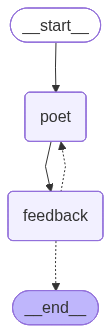

In [3]:
from langgraph.types import interrupt
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import BaseMessage
from langchain_core.messages.content import create_text_block, create_image_block, ImageContentBlock
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from typing import Literal, List, cast
from pathlib import Path
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI

class State(BaseModel):
    story:str=''
    need_reiteration:bool=True
    chat_memory:List[SystemMessage|HumanMessage|AIMessage]=[
        SystemMessage(content="You are horror story writer, you think of new bezar ideas and write unique short horror story"),
        HumanMessage(content="Write a very short horror story paragraph, indian village style")
    ]

class AI2HumanRequest(BaseModel):
    req:str="Give feedback on the story I just wrote"
    data:str=''
class Human2AIRequest(BaseModel):
    approved:bool
    msg:str=''

def extract_text(message: BaseMessage) -> str:
    """Narrows the type for the linter and extracts clean text."""
    content = message.content
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        # Filter for text blocks and join them
        return "".join(
            item if isinstance(item, str) else item.get("text", "") 
            for item in content
        )
    return ""

def genStory(state:State)->State:
    llm=ChatGoogleGenerativeAI(model='gemini-3-flash-preview', temperature=0.9,google_api_key=os.getenv("GOOGLE_FREE_API_KEY"))
    story_response=llm.invoke(state.chat_memory)
    state.story=extract_text(story_response)
    return state

def getFeedback(state:State)->State:
    feedback=cast(Human2AIRequest, interrupt(AI2HumanRequest(data=state.story)))
    state.need_reiteration=not feedback.approved
    return state

def routeEdit(state:State)->Literal['poet','__end__']:
    return 'poet' if state.need_reiteration else '__end__'

graph=StateGraph(State)

graph.add_node('poet', genStory)
graph.add_node("feedback", getFeedback)

graph.add_edge(START, 'poet')
graph.add_edge('poet','feedback')
graph.add_conditional_edges('feedback',routeEdit)


ckptr=MemorySaver()
workflow=graph.compile(checkpointer=ckptr)
workflow

In [4]:
from langchain_core.runnables import RunnableConfig
from langgraph.types import Command
cfg:RunnableConfig={'configurable':{'thread_id':'thread1'}}
workflow.invoke(State(), config=cfg)
while True:
    snapshot=workflow.get_state(config=cfg)
    if not snapshot.values.get("need_reiteration"):
        print("Final Story:\n", snapshot.values.get("story"))
        break
    if not snapshot.interrupts:
        workflow.invoke(None, config=cfg)
        continue
    bulk_intrerrupt_responses={}
    for inter in snapshot.interrupts:
        if isinstance(inter.value, AI2HumanRequest):
            print("Story:\n", inter.value.data,"\n-------")
            user_input=input("Do you approve the story? (y/n): ")
            approved=(user_input.strip().lower() in ['y','yes'])
            user_msg=input(inter.value.req)
            feedback=Human2AIRequest(approved=approved, msg=user_msg)
            bulk_intrerrupt_responses[inter.id]=feedback
    workflow.invoke(Command(resume=bulk_intrerrupt_responses), config=cfg)


Story:
 The moon hung low over the parched fields of Dhokla-Pur, but it wasn't the jackals that kept young Raju awake; it was the rhythmic *thump-squelch* of his grandmother’s mortar and pestle in the dead of night. Creeping to the kitchen, he saw her grinding not spices, but the discarded milk teeth of the village children, their calcium white turning into a glowing, iridescent paste. She didn't look up as she smeared the slurry onto the mud walls, but Raju froze when he noticed the walls weren't drying—they were *blinking*. Thousands of tiny, wet eyes were opening within the clay, and as his grandmother turned, her own face was a smooth, featureless expanse of skin, her stolen eyes already peering out from the corner of the room, watching him with a hunger that smelled of wet earth and old copper. 
-------
Final Story:
 The moon hung low over the parched fields of Dhokla-Pur, but it wasn't the jackals that kept young Raju awake; it was the rhythmic *thump-squelch* of his grandmother’

In [27]:
for snapshot in workflow.get_state_history(cfg):
    print(snapshot)

StateSnapshot(values={'story': "Under the jaundice-yellow moon of Malpur, the old iron hand-pump in the courtyard didn't yield water, but a thick, rhythmic *thumping* that vibrated through the parched earth like a buried heartbeat. When young Arjun pressed the rusted handle, it wasn't groundwater that spilled into his brass bucket, but a torrent of warm, severed human tongues, each one still twitching with the wet friction of unfinished prayers. As the pile rose, the village's deaf-mute temple priest began to scream in a dozen different stolen voices, his own jaw unhinging like a split pomegranate to reveal a miniature iron handle cranking feverishly behind his teeth.", 'need_reiteration': False, 'chat_memory': [SystemMessage(content='You are horror story writer, you think of new bezar ideas and write unique short horror story', additional_kwargs={}, response_metadata={}), HumanMessage(content='Write a very short horror story paragraph, indian village style', additional_kwargs={}, resp

In [5]:
workflow.get_state(cfg)

StateSnapshot(values={'story': "The moon hung low over the parched fields of Dhokla-Pur, but it wasn't the jackals that kept young Raju awake; it was the rhythmic *thump-squelch* of his grandmother’s mortar and pestle in the dead of night. Creeping to the kitchen, he saw her grinding not spices, but the discarded milk teeth of the village children, their calcium white turning into a glowing, iridescent paste. She didn't look up as she smeared the slurry onto the mud walls, but Raju froze when he noticed the walls weren't drying—they were *blinking*. Thousands of tiny, wet eyes were opening within the clay, and as his grandmother turned, her own face was a smooth, featureless expanse of skin, her stolen eyes already peering out from the corner of the room, watching him with a hunger that smelled of wet earth and old copper.", 'need_reiteration': False, 'chat_memory': [SystemMessage(content='You are horror story writer, you think of new bezar ideas and write unique short horror story', a

In [7]:
State(**workflow.get_state(cfg).values)

State(story="The moon hung low over the parched fields of Dhokla-Pur, but it wasn't the jackals that kept young Raju awake; it was the rhythmic *thump-squelch* of his grandmother’s mortar and pestle in the dead of night. Creeping to the kitchen, he saw her grinding not spices, but the discarded milk teeth of the village children, their calcium white turning into a glowing, iridescent paste. She didn't look up as she smeared the slurry onto the mud walls, but Raju froze when he noticed the walls weren't drying—they were *blinking*. Thousands of tiny, wet eyes were opening within the clay, and as his grandmother turned, her own face was a smooth, featureless expanse of skin, her stolen eyes already peering out from the corner of the room, watching him with a hunger that smelled of wet earth and old copper.", need_reiteration=False, chat_memory=[SystemMessage(content='You are horror story writer, you think of new bezar ideas and write unique short horror story', additional_kwargs={}, resp

In [8]:
cast(State, workflow.get_state(cfg).values)

{'story': "The moon hung low over the parched fields of Dhokla-Pur, but it wasn't the jackals that kept young Raju awake; it was the rhythmic *thump-squelch* of his grandmother’s mortar and pestle in the dead of night. Creeping to the kitchen, he saw her grinding not spices, but the discarded milk teeth of the village children, their calcium white turning into a glowing, iridescent paste. She didn't look up as she smeared the slurry onto the mud walls, but Raju froze when he noticed the walls weren't drying—they were *blinking*. Thousands of tiny, wet eyes were opening within the clay, and as his grandmother turned, her own face was a smooth, featureless expanse of skin, her stolen eyes already peering out from the corner of the room, watching him with a hunger that smelled of wet earth and old copper.",
 'need_reiteration': False,
 'chat_memory': [SystemMessage(content='You are horror story writer, you think of new bezar ideas and write unique short horror story', additional_kwargs={}

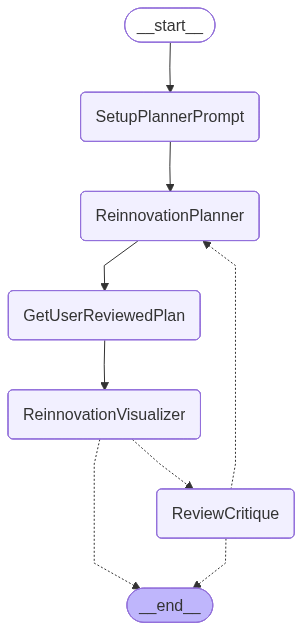

In [10]:
from langchain_core.messages.content import create_text_block, create_image_block, ImageContentBlock
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field
from typing import Literal, List, cast
from PIL import Image
import io
import os
from pathlib import Path
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

import base64
def local_image_message_content(path:Path)->ImageContentBlock:
    return create_image_block(
        base64=base64.b64encode(path.read_bytes()).decode("utf-8"),
        mime_type=f"image/{path.suffix.lstrip('.')}"
    )

class Plans(BaseModel):
    steps: List[str] = Field(
        description="""
        List of step by step re innovation plans.
        Each step contains detailed description about what change to made, what to add, what to remove, what to change, where to apply, how to apply etc,
        with proper description of goal aesthetic, look, also position, color description etc,
        so that any editor specialist can read it and apply these changes on appropriate position, item on the actual room image precisely.
        """,
        default=[]
    )
class ReviewResponse(BaseModel):
    approved: bool = Field(
        default=False,
        description="Whether the re innovation is approved or not."
    )
    comments: None| str = Field(
        default=None,
        description="Constructive criticism regarding the re innovation image quality, in case of rejection."
    )

class AgentState(BaseModel):
    max_critique_iterations:int=Field(
        default=3,
        description="Maximum number of critique iterations allowed."
    )
    current_critique_iteration:int=Field(
        default=0,
        description="Current critique iteration count."
    )
    generation_iteration:int=Field(
        default=0,
        description="Current generation iteration count."
    )
    planner_memory: List[SystemMessage | HumanMessage | AIMessage]=Field(
        default=[],
        description="History of previous edit patches"
    )
    current_edit_plan: Plans= Field(
        default=Plans(),
        description="Step by step plan of editing the actual image for re innovation"
    )
    user_edit_plan: str= Field(
        default="",
        description="Edit plan after user reviewed and edited the plan proposed by the agent."
    )
    current_gen_path: Path= Field(
        default=Path(),
        description="Path to the image generated"
    )
    critique_review: ReviewResponse= Field(
        default=ReviewResponse(),
        description="Critique review of the generated image."
    )
    #================================
    #Mendatory inputs
    room_image_path: Path= Field(
        description="Path to the image of the room to be re innovated."
    )
    theme_samples: List[Path] = Field(
        description="List of paths to sample images representing the desired theme for the room."
    )
    reinnovation_description: str = Field(
        description="A detailed description of the desired re-innovation for the room."
    )



def setupPlanPrompt(state: AgentState) -> AgentState:
    print("setting up planning prompt")
    state.planner_memory.extend(
        [
            SystemMessage(
                content="""
                You are an expert in room re innovation.
                You look into the room image provided provided, analyze its look, aesthetics, then you also look into the style inspiration images (if any), descriptions.
                Based on the desired look and aesthetic you make step by step plan of what changes to made.
                your step by step plan should not include modification of solid structures, 
                like for example: room size, window position, size, fixed light-fan-switch board positions, wiring, tiles etc.
                Your step by step re innovation plan should only contain modification, addition or removal of movable items. 
                some example are: portrait, table light, small table, bed, bedsheet, carpet, aquarium, twinkle lights etc etc.
                Give the output as json format.
                output example:
                ```
                { 
                    steps: [
                        "change the curtain to a beautiful red colored silky curtain with lily flower on it",
                        "apply maroon plastic paint on the light pink wall on the left side",
                    ]
                }
                ```
                """
            ),
            HumanMessage(
                content=[
                    dict(
                        create_text_block(text=f"""
                        The following is the image of the room, on which you need to plan re innovation:
                        """)
                    ),
                    dict(
                        local_image_message_content(path=state.room_image_path)
                    ),
                    dict(
                        create_text_block(text=f"""
                            The following is the description about the re innovation I want:
                            ---
                            {state.reinnovation_description}
                            ---

                            The following are some sample images of the theme I want:
                        """)
                    ),
                    *[
                        dict(
                            local_image_message_content(path=img_path)
                        )
                        for img_path in state.theme_samples
                    ]
                ]
            ),
        ]
    )
    return state



def planReinnovation(state: AgentState) -> AgentState:
    print("planning re innovation")
    llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", temperature=0.8, google_api_key=os.getenv("GOOGLE_FREE_API_KEY")).with_structured_output(Plans)
    state.current_edit_plan = cast(Plans,llm.invoke(state.planner_memory))
    print(f"Proposed step by step plan:\n{state.current_edit_plan.steps}")
    return state

def getUserReviewedPlan(state: AgentState) -> AgentState:
    print("getting user reviewed plan")
    # TODO:  This function can be implemented to get user-reviewed plans.
    state.user_edit_plan=("\n-- ").join(state.current_edit_plan.steps)
    print(f"Actionable plan proposed to user:\n{state.user_edit_plan}")
    state.planner_memory.append(
        HumanMessage(
            content=f"""
            The following is the step by step re innovation plan approved by the user:
            ---
            {state.user_edit_plan}
            ---
            """
        )
    )
    return state

def renderPlan(state: AgentState)->AgentState:
    print("rendering plan to generate re innovated image")
    message=[
        SystemMessage(
            content="""
                You are an image editor, expert in re innovating interior room design by following step by step editing plans given.
                you generate high fidality beautiful aesthetic room based on the image of the room, planning given to you.
                You only change the movable items in the scene. You do not add or modify extra item that is not present in the plan.
                You do not change rigit structure of the room and do not change the visual perspective of the given image.
            """
        ),
        HumanMessage(
            content=[
                dict(
                    create_text_block(
                        text="The following is the image, on which you need to apply the style changes and do the re innovation on:"
                    )
                ),
                dict(local_image_message_content(path=state.room_image_path)),
                dict(
                    create_text_block(
                        text=f"""
                        The following is the step by step plan of re innovation, apply these to the given image:
                        {state.user_edit_plan}
                        """
                    )
                )
            ]
        )
    ]
    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-image", temperature=0.9,google_api_key=os.getenv("GOOGLE_PAID_API_KEY"))
    response = llm.invoke(message)
    print("Received response from image generation LLM")
    image_folder=Path("images")
    file_name=f"generation_{state.generation_iteration}.png"
    save_path=image_folder/file_name
    for block in response.content:
        if isinstance(block, dict) and block.get("type") == "image_url":
            img_data = block["image_url"]["url"].split(",")[1]
            img_bytes = base64.b64decode(img_data)
            image = Image.open(io.BytesIO(img_bytes))
            image.save(save_path)
            print(f"Image saved successfully as {file_name}")

    state.generation_iteration+=1
    state.current_gen_path=save_path
    state.planner_memory.append(
        AIMessage(
            content=[
                dict(
                    create_text_block(
                        text="The following is the re innovated image after applying the plan:"
                    )
                ),
                dict(
                    local_image_message_content(path=state.current_gen_path)
                )
            ]
        )
    )
    return state



def reviewCritique(state: AgentState) -> AgentState:
    print("reviewing and critiquing the generated image")
    messages=[
        SystemMessage(
            content="""
            You are an expert in judging the aesthetic quality of room re innovation.
            You look into the original room image, the re innovated image, and the plan that was followed to do the re innovation.
            Accept if the re innovation has been done according to the plan, if the re innovation looks decent enough, without any clear vizual artifact.
            Reject only if the re innovation does not follow the plan, does something out of plan, skip some plan, 
            or if the re innovation looks bad, unaesthetic, ugly, 
            or if the image of the re innovation has any vizual artifacts, distortions, visual glitches etc that make it sloppy, unrealistic,
            or if the re innovation changed any solid structure of the room etc.
            In case of rejection, give constructive criticism regarding what went wrong, what could have been better etc so that planning expert reads it and make better plan.
            You need to give feedback in json format. For example:
            ```
            #In case of acceptance
            {
                "approved": true,
                "comments": "The re innovation looks decent." #This is optional in case of acceptance
            }

            #In case of rejection
            {
                "approved": false,
                "comments": "The re innovation did extra changes not mentioned in the plan. The carpet looks distorted. Added separate window that is not actually present in the room."
            }
            ```
            """
        ),
        HumanMessage(
            content=[
                dict(
                    create_text_block(
                        text=f"""
                        The following was the plan of re innovation approved by the user:
                        ---------------
                        {state.user_edit_plan}
                        ---------------

                        The following is the original image of the room before re innovation:

                        """
                    )
                ),
                dict(
                    local_image_message_content(path=state.room_image_path)
                ),
                dict(
                    create_text_block(
                        text="""
                        The following is the re innovated image of the room after applying the re innovation plan:

                        """
                    )
                ),
                dict(
                    local_image_message_content(path=state.current_gen_path)
                )
            ]
        )
    ]
    llm= ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0.2,google_api_key=os.getenv("GOOGLE_PAID_API_KEY")).with_structured_output(ReviewResponse)
    state.critique_review=cast(ReviewResponse,llm.invoke(messages))
    print(f"Critique review: \nApproved={state.critique_review.approved}, \nComments={state.critique_review.comments}")
    if not state.critique_review.approved:
        state.planner_memory.append(
            AIMessage(
                content=f"""
                The critique rejected the re innovation. It gave the following feedback:
                ---------------
                {state.critique_review.comments}
                ---------------
                Now your job is to make a better step by step re innovation plan addressing these issues.
                Do not modify anything else which are not mentioned in the critique feedback.
                """
            )
        )
    return state


def editRouter(state: AgentState) -> Literal["ReviewCritique", "__end__"]:
    if state.current_critique_iteration < state.max_critique_iterations:
        state.current_critique_iteration+=1
        return "ReviewCritique"
    else:
        return "__end__"


def critiqueRouter(state: AgentState) -> Literal["ReinnovationPlanner", "__end__"]:
    if state.critique_review.approved:
        return "__end__"
    else:
        state.current_critique_iteration+=1
        return "ReinnovationPlanner"

workflow = StateGraph(AgentState)

workflow.add_node("SetupPlannerPrompt", setupPlanPrompt)
workflow.add_node("ReinnovationPlanner", planReinnovation)
workflow.add_node("GetUserReviewedPlan", getUserReviewedPlan)
workflow.add_node("ReinnovationVisualizer", renderPlan)
workflow.add_node("ReviewCritique", reviewCritique)

workflow.add_edge(START, "SetupPlannerPrompt")
workflow.add_edge("SetupPlannerPrompt", "ReinnovationPlanner")
workflow.add_edge("ReinnovationPlanner", "GetUserReviewedPlan")
workflow.add_edge("GetUserReviewedPlan", "ReinnovationVisualizer")
workflow.add_conditional_edges("ReinnovationVisualizer",editRouter)
workflow.add_conditional_edges("ReviewCritique",critiqueRouter)

app=workflow.compile()
app


In [11]:
initial_state=AgentState(
    room_image_path=Path("samples/room.jpeg"),
    theme_samples=[
        Path("samples/bohemian_g.jpeg"),
        Path("samples/modern_contemporary.png"),
    ],
    reinnovation_description="""
    balances structure with warmth. The modern foundation provides clean lines, controlled symmetry, and a restrained color palette, ensuring the room feels intentional rather than chaotic. 
    Onto this base, bohemian elements introduce texture and emotion—layered fabrics, natural materials, plants, and artisanal décor soften the rigidity of modern design. 
    Lighting plays a critical role: modern, indirect or pendant lighting establishes clarity, while warm, decorative lights add intimacy. 
    The overall vibe is relaxed but confident—polished without feeling sterile, expressive without becoming messy.
    This blend suits someone who wants sophistication with personality, order with a visible human touch.
    """
)
final_state=app.invoke(initial_state)

setting up planning prompt
planning re innovation
Proposed step by step plan:
['Apply a deep charcoal or matte slate grey paint to the main red wall to create a sophisticated, modern backdrop that allows decor to pop.', "Replace the purple patterned curtains with floor-to-ceiling neutral linen curtains in an oatmeal or light grey shade to soften the room's edges.", 'Remove the blue fabric from the small upper window and install a minimalist black-out roller blind or a sleek wooden slat blind.', 'Swap the current floral bedsheet for a high-quality white or cream linen bedding set to establish a clean, modern base.', 'Layer the bed with a chunky knit throw blanket in a warm terracotta color and add a mix of textured throw pillows featuring macrame and geometric patterns.', 'Hang a large, intricate macrame wall hanging or a woven textile tapestry above the headboard to introduce bohemian texture and warmth.', 'Install warm-white LED string lights along the top perimeter of the walls or dr

In [17]:
final_state.get("current_gen_path")

PosixPath('images/generation_0.png')

In [18]:
AgentState(**final_state).current_gen_path

PosixPath('images/generation_0.png')

AttributeError: 'dict' object has no attribute 'current_gen_path'